# Data Cleaning and Preprocessing


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Dataset to df

In [3]:
path_to_data = "../data/Titanic-Dataset.csv"

df = pd.read_csv(path_to_data)

## Explore Data

### Describe data

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Display rows of data

In [5]:
# display first 10 rows
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [6]:
# display last 5 rows
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Display data types

In [7]:
# display non-null count and datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### display null values

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Handling missing (null) values

### mean imputation

In [9]:
# for Age column (only numeric data with null)
mean_val = df['Age'].mean()

df['Age'] = df['Age'].fillna(mean_val)

# verify all null values in Age are filled
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### median imputation

In [10]:
# for Age column (only numeric data with null)
median_val = df['Age'].median()

df['Age'] = df['Age'].fillna(median_val)

# verify all null values in Age are filled
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Converting Categorical to numerical features

### Find categorical values

In [11]:
# list rows for referece
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,NaN,C


In [12]:
# has too many unique values, cant be categorized
df['Name'].nunique()

891

In [13]:
# Categorical value (male, female)
df['Sex'].nunique()

2

In [14]:
# has too many unique values, cant be categorized
df['Ticket'].nunique()

681

In [15]:
# has too many unique values, cant be categorized
df['Cabin'].nunique()

147

In [16]:
# Categorical value (S, C, Q)
df['Embarked'].nunique()

3

### Categorical to numerical values

In [17]:
# Map male to 1 and female to 0
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

df['Sex']

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int64

In [18]:
# 1. Fill the 2 missing values with the most common port ('S') first
df['Embarked'] = df['Embarked'].fillna('S')

# 2. Map S to 0, C to 1, and Q to 2
df['Embarked'] = df['Embarked'].replace({'S': 0, 'C': 1, 'Q': 2})

df['Embarked']

0      0
1      1
2      0
3      0
4      0
      ..
886    0
887    0
888    0
889    1
890    2
Name: Embarked, Length: 891, dtype: object

## Normalization

### Find what to Normalize

In [19]:
# we choose Age and Fare as they are continous value
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,0


### Z-Score Normalization [ (Value - Mean) / Standard Deviation ]

In [20]:
# Z-Score Normalization for Age
df['Age'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()
df['Age']

0     -0.592148
1      0.638430
2     -0.284503
3      0.407697
4      0.407697
         ...   
886   -0.207592
887   -0.822881
888    0.000000
889   -0.284503
890    0.176964
Name: Age, Length: 891, dtype: float64

In [21]:
# Z-Score Normalization for Fare
df['Fare'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()
df['Fare']

0     -0.502163
1      0.786404
2     -0.488580
3      0.420494
4     -0.486064
         ...   
886   -0.386454
887   -0.044356
888   -0.176164
889   -0.044356
890   -0.492101
Name: Fare, Length: 891, dtype: float64

## Outliers

### Visualize Outliers


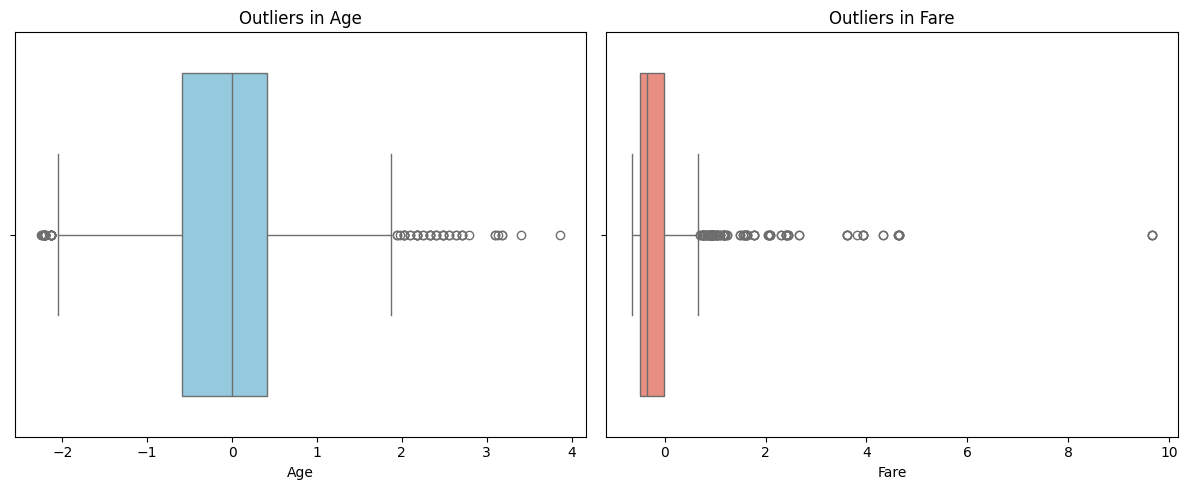

In [27]:
# Set up a side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot boxplot for Age
sns.boxplot(ax=axes[0], x=df['Age'], color='skyblue')
axes[0].set_title('Outliers in Age')

# Plot boxplot for Fare
sns.boxplot(ax=axes[1], x=df['Fare'], color='salmon')
axes[1].set_title('Outliers in Fare')

fig.tight_layout()
plt.show()

### Outlier Removal (IQR method)

In [28]:
# Select the columns you want to filter
target_cols = ['Age', 'Fare']

for col in target_cols:
    # 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    # 2. Calculate the Interquartile Range
    iqr = q3 - q1
    
    # 3. Define the upper and lower boundary cutoffs
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # 4. Filter the DataFrame to keep only values within the bounds
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Dataset shape after removing outliers: {df.shape}")

Dataset shape after removing outliers: (718, 12)


### visualize data after removal of outliers

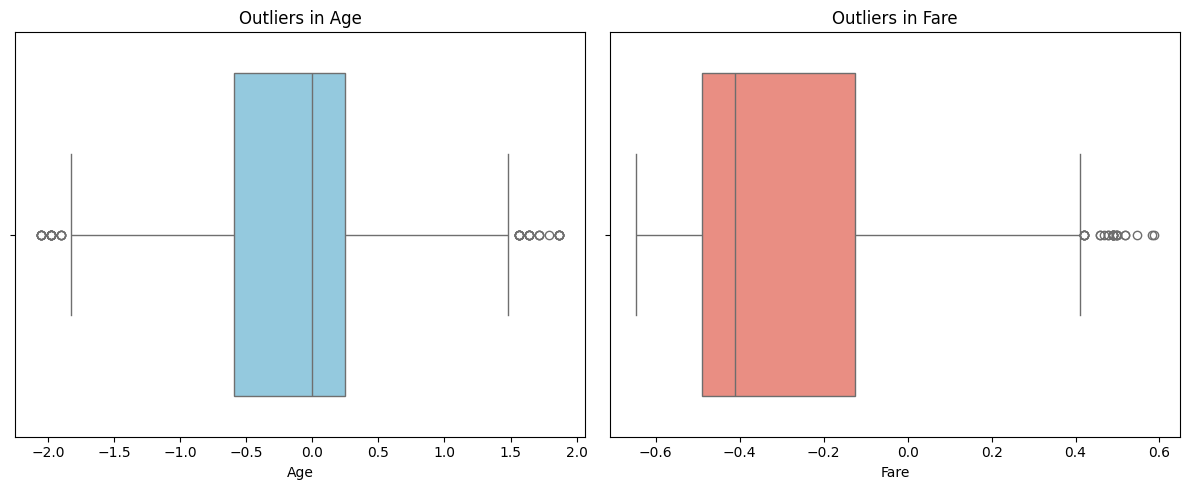

In [29]:
# Set up a side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot boxplot for Age
sns.boxplot(ax=axes[0], x=df['Age'], color='skyblue')
axes[0].set_title('Outliers in Age')

# Plot boxplot for Fare
sns.boxplot(ax=axes[1], x=df['Fare'], color='salmon')
axes[1].set_title('Outliers in Fare')

fig.tight_layout()
plt.show()